In [70]:
from pyscf import gto, scf, cc

a = 3 # bond length in a cluster
d = 100 # distance between each cluster
unit = 'b' # unit of length
na = 2 # size of a cluster (monomer)
nc = 1 # set as integer multiple of monomers
spin = 0 # spin per monomer
frozen = 2 # frozen orbital per monomer
elmt = 'N'
basis = 'sto6g'
# for nc in nc_list:
atoms = ""
for n in range(nc*na):
    shift = ((n - n % na) // na) * (d-a)
    atoms += f"{elmt} {n*a+shift:.5f} 0.00000 0.00000 \n"

mol = gto.M(atom=atoms, basis="sto6g", unit='B', spin=0, verbose=4)
mol.build()

mf = scf.UHF(mol)
mf.kernel()

mo = mf.stability()[0]
dm = mf.make_rdm1(mo,mf.mo_occ)
mf.kernel(dm0=dm)
mo = mf.stability()[0]
dm = mf.make_rdm1(mo,mf.mo_occ)
mf.kernel(dm0=dm)
mo = mf.stability()[0]
dm = mf.make_rdm1(mo,mf.mo_occ)
mf.kernel(dm0=dm)
mo = mf.stability()[0]

nfrozen = 2
mycc = cc.CCSD(mf,frozen=nfrozen)
mycc.kernel()[0]

System: uname_result(system='Linux', node='sharmagroup-rn', release='6.17.0-14-generic', version='#14~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Thu Jan 15 15:52:10 UTC 2', machine='x86_64')  Threads 16
Python 3.11.14 (main, Oct 21 2025, 18:31:21) [GCC 11.2.0]
numpy 2.3.1  scipy 1.16.2  h5py 3.14.0
Date: Thu Mar  5 14:51:15 2026
PySCF version 2.12.1
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD (branch master) f0861da51f017364d8bbaa20b742a94f3733305f

[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 2
[INPUT] num. electrons = 14
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry False subgroup None
[INPUT] Mole.unit = B
[INPUT] Symbol           X                Y                Z      unit          X                Y                Z       unit  Magmom
[INPUT]  1 N      0.000000000000   0.000000000000   0.000000000000 AA   

np.float64(-0.08558530097417516)

In [71]:
import numpy as np
print(f'largest t1a: {np.abs(mycc.t1[0]).max()}')
print(f'largest t1b: {np.abs(mycc.t1[1]).max()}')
print(f'largest t2aa: {np.abs(mycc.t2[0]).max()}')
print(f'largest t2ab: {np.abs(mycc.t2[1]).max()}')
print(f'largest t2bb: {np.abs(mycc.t2[2]).max()}')

largest t1a: 0.2252101444650323
largest t1b: 0.22915892876393198
largest t2aa: 0.0402389498754379
largest t2ab: 0.3608629551567975
largest t2bb: 0.040944491122310786


In [72]:
# example for PT2

options = {'n_eql': 3,
           'n_prop_steps': 50,
            'n_ene_blocks': 1,
            'n_sr_blocks': 5,
            'n_blocks': 50,
            'n_walkers': 300,
            'seed': 2,
            'walker_type': 'uhf',
            'trial': 'ustoccsd2',
            'nslater': 5,
            'dt':0.005,
            'use_gpu': False,
            }

from ad_afqmc.prop_unrestricted.mixed_wave import prep
import jax
jax.config.update("jax_enable_x64", True)
prep.prep_afqmc(mycc,chol_cut=1e-5)
# prop_unrestricted.run_afqmc(options,nproc=1)
option_file='options.bin'
import pickle
with open(option_file, 'wb') as f:
    pickle.dump(options, f)

#
# Preparing AFQMC calculation
# Calculating Cholesky integrals
# Finished calculating Cholesky integrals
#
# Size of the correlation space:
# Number of electrons: (5, 5)
# Number of basis functions: 8
# Number of Cholesky vectors: 38
#


In [74]:
import time
import numpy as np
from jax import random
from jax import numpy as jnp
from functools import partial 

ham_data, ham, prop, trial, wave_data, sampler, options = (prep._prep_afqmc())

init_time = time.time()

### initialize propagation
init_walkers = None
trial_rdm1 = trial.get_rdm1(wave_data)
if "rdm1" not in wave_data:
    wave_data["rdm1"] = trial_rdm1
ham_data = ham.build_measurement_intermediates(ham_data, trial, wave_data)
ham_data = ham.build_propagation_intermediates(ham_data, prop, trial, wave_data)

prop_data = prop.init_prop_data(trial, wave_data, ham_data, init_walkers)
if jnp.abs(jnp.sum(prop_data["overlaps"])) < 1.0e-6:
    raise ValueError(
        "Initial overlaps are zero. Pass walkers with non-zero overlap."
    )
prop_data["key"] = random.PRNGKey(options["seed"])

prop_data["overlaps"] = trial.calc_overlap(prop_data["walkers"], wave_data)
prop_data["n_killed_walkers"] = 0

e_init= jnp.real(trial.calc_energy(prop_data["walkers"], ham_data, wave_data)[0])
prop_data["e_estimate"] = e_init
prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

print(e_init)
print(e_init-mf.e_tot)

# Decomposing Unrestricted T2 amplitudes
# Throw 0 vectors in T2 deomposition
# SVD cutoff = 1.00e-08 | error = 6.68e-15
# number of T2 decomposition vectors 30
# nelec: (5, 5)
# norb: 8
# nchol: 38
# n_eql: 3
# n_prop_steps: 50
# n_ene_blocks: 1
# n_sr_blocks: 5
# n_blocks: 50
# n_walkers: 300
# seed: 2
# walker_type: uhf
# trial: ustoccsd2
# nslater: 5
# dt: 0.005
# use_gpu: False
# n_exp_terms: 6
# n_batch: 1
# max_error: 0.001
-108.5029673602465
2.134331913339338e-05


In [75]:
from jax import jit, lax

@partial(jit, static_argnums=(0,3,4))
def _block(
    self,
    prop_data: dict,
    ham_data: dict,
    prop,
    trial,
    wave_data: dict
    ):
    """Block scan function. Propagation and energy calculation."""

    prop_data["key"], subkey = random.split(prop_data["key"])
    fields = random.normal(
        subkey,
        shape=(
            self.n_prop_steps,
            prop.n_walkers,
            self.n_chol,
        ),
    )
    _step_scan_wrapper = lambda x, y: self._step_scan(
        x, y, ham_data, prop, trial, wave_data
    )
    prop_data, _ = lax.scan(_step_scan_wrapper, prop_data, fields)
    prop_data["n_killed_walkers"] += prop_data["weights"].size - jnp.count_nonzero(
        prop_data["weights"]
    )

    # fields_x for T2 decomposition
    # prop_data["key"], subkey = random.split(prop_data["key"])
    # fields_x = random.normal(
    #     subkey,
    #     shape=(
    #         prop.n_walkers,
    #         trial.nslater,
    #         wave_data['tau'].shape[0],
    #     ),
    # )

    # xtaus = jnp.einsum("wsg,gia->wsia", fields_x, wave_data['tau'])
    xtaus = trial.get_xtaus(prop_data, wave_data, prop)

    prop_data = prop.orthonormalize_walkers(prop_data)
    overlap_hf = trial.calc_overlap(prop_data["walkers"], wave_data)
    prop_data["overlaps"] = overlap_hf
    overlap_ci, energy_ci = trial.calc_energy_cid(prop_data["walkers"], ham_data, wave_data)
    numerator_cr, denominator_cr = trial.calc_correction(prop_data["walkers"], xtaus, ham_data, wave_data)

    num_ci = overlap_ci * energy_ci / overlap_hf
    den_ci = overlap_ci / overlap_hf
    num_cr = numerator_cr / overlap_hf
    den_cr = denominator_cr / overlap_hf

    whf = prop_data["weights"]

    blk_whf = jnp.sum(whf)

    blk_num_ci = jnp.sum(whf * num_ci) / blk_whf
    blk_den_ci = jnp.sum(whf * den_ci) / blk_whf
    blk_num_cr = jnp.sum(whf * num_cr) / blk_whf
    blk_den_cr = jnp.sum(whf * den_cr) / blk_whf

    prop_data = prop.stochastic_reconfiguration_local(prop_data)
    prop_data["overlaps"] = trial.calc_overlap(prop_data["walkers"], wave_data)

    return prop_data, (blk_whf, blk_num_ci, blk_den_ci, blk_num_cr, blk_den_cr)


In [76]:
neql = 200
block_time = prop.dt * sampler.n_prop_steps

for n in range(neql):
    prop_data, (whf, num_ci, den_ci, num_cr, den_cr) \
        = _block(sampler, prop_data, ham_data, prop, trial, wave_data)

    eci = num_ci / den_ci
    ecc = (num_ci + num_cr) / (den_ci + den_cr)

    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * eci.real
    key = prop_data["key"]

    print(f" {(n+1)*block_time:.2f}  {eci.real:.6f}  {num_cr.real:.6f}  {den_cr.real:.6f}  {ecc.real:.6f}  {time.time() - init_time:.2f} ")

 0.25  -108.587855  -0.045490  0.000411  -108.588657  7.83 
 0.50  -108.587688  0.023236  -0.000231  -108.589480  12.13 
 0.75  -108.588236  -0.006153  0.000034  -108.590586  12.30 
 1.00  -108.588576  -0.057214  0.000507  -108.590606  12.47 
 1.25  -108.588652  -0.029048  0.000244  -108.591030  12.64 
 1.50  -108.588273  -0.215786  0.001976  -108.589355  12.81 
 1.75  -108.588954  -0.295947  0.002729  -108.588628  12.98 
 2.00  -108.589111  -0.331124  0.003034  -108.590631  13.15 
 2.25  -108.589619  -0.270012  0.002476  -108.590660  13.32 
 2.50  -108.589098  -0.371963  0.003421  -108.589476  13.49 
 2.75  -108.587840  -0.336430  0.003075  -108.590005  13.66 
 3.00  -108.590242  -0.094080  0.000833  -108.593300  13.83 
 3.25  -108.590066  -0.363766  0.003349  -108.590190  14.00 
 3.50  -108.592652  -0.942082  0.008687  -108.591626  14.17 
 3.75  -108.590214  -0.504930  0.004618  -108.593111  14.34 
 4.00  -108.590187  -0.883726  0.008065  -108.596723  14.51 
 4.25  -108.587015  -0.83

In [84]:
nsample = 1000
whf_sp = np.zeros(nsample,dtype="float64")
numci_sp = np.zeros(nsample,dtype="complex128")
denci_sp = np.zeros(nsample,dtype="complex128")#float64")
numcr_sp = np.zeros(nsample,dtype="complex128")
dencr_sp = np.zeros(nsample,dtype="complex128")
ecisd_sp = np.zeros(nsample,dtype="float64")
eccsd_sp = np.zeros(nsample,dtype="float64")

for n in range(nsample):
    prop_data, (whf, numci, denci, numcr, dencr) \
        = _block(sampler, prop_data, ham_data, prop, trial, wave_data)
    key = prop_data["key"]
    
    prop_data = prop.orthonormalize_walkers(prop_data)
    prop_data = prop.stochastic_reconfiguration_local(prop_data)

    whf_sp[n] = whf

    numci_sp[n] = numci
    denci_sp[n] = denci
    numcr_sp[n] = numcr
    dencr_sp[n] = dencr

    ecisd_sp[n] = (numci/denci).real
    eccsd_sp[n] = ((numci+numcr)/(denci+dencr)).real

    whf = np.sum(whf_sp[:n+1])
    whf_numci = np.sum(whf_sp[:n+1] * numci_sp[:n+1])
    whf_denci = np.sum(whf_sp[:n+1] * denci_sp[:n+1])
    whf_numcr = np.sum(whf_sp[:n+1] * numcr_sp[:n+1])
    whf_dencr = np.sum(whf_sp[:n+1] * dencr_sp[:n+1])

    numci = whf_numci / whf
    denci = whf_denci / whf
    eci = numci / denci

    numcr = whf_numcr / whf
    dencr = whf_dencr / whf
    ecc = (numci + numcr) / (denci + dencr)

    if n > 1:
        # partial_eci/partial_num, partial_eci/partial_don
        deci = [1/denci, -numci/denci**2]
        covci = np.cov([numci_sp[:n+1], denci_sp[:n+1]])
        eci_err = np.sqrt(deci @ covci @ deci) / np.sqrt((n))
        
        # partial_ecc...
        decc = [1/(denci+dencr), 
                1/(denci+dencr), 
                -(numci+numcr)/(denci+dencr)**2, 
                -(numci+numcr)/(denci+dencr)**2,
                ]
        covcc = np.cov([numci_sp[:n+1], numcr_sp[:n+1], denci_sp[:n+1], dencr_sp[:n+1]])
        ecc_err = np.sqrt(decc @ covcc @ decc) / np.sqrt((n))

        ecisd = ecisd_sp[:n+1].mean()
        ecisd_err = np.std(ecisd_sp[:n+1])/np.sqrt(len(ecisd_sp[:n+1]))
        eccsd = eccsd_sp[:n+1].mean()
        eccsd_err = np.std(eccsd_sp[:n+1])/np.sqrt(len(eccsd_sp[:n+1]))

        print(f" {n+1}  {eci.real:.6f}  {eci_err.real:.6f}  {ecisd:.6f}  {ecisd_err:.6f} {ecc.real:.6f}  {ecc_err.real:.6f}  {eccsd:.6f}  {eccsd_err:.6f}")

 3  -108.590167  0.005173  -108.590182  0.003347 -108.619387  0.013624  -108.619358  0.004333
 4  -108.589964  0.003639  -108.589978  0.002516 -108.614156  0.010933  -108.614186  0.005534
 5  -108.590162  0.002730  -108.590171  0.002020 -108.611982  0.008989  -108.611994  0.004842
 6  -108.589367  0.002351  -108.589379  0.001833 -108.609261  0.007891  -108.609288  0.004731
 7  -108.590384  0.002459  -108.590375  0.001822 -108.612565  0.007565  -108.612563  0.005063
 8  -108.590929  0.002207  -108.590922  0.001674 -108.609932  0.007133  -108.609991  0.005041
 9  -108.590864  0.001966  -108.590859  0.001489 -108.606849  0.007037  -108.606922  0.005334
 10  -108.590493  0.001966  -108.590481  0.001388 -108.606526  0.006987  -108.606547  0.004814
 11  -108.590490  0.001774  -108.590479  0.001261 -108.605571  0.006362  -108.605599  0.004468
 12  -108.590731  0.001677  -108.590722  0.001179 -108.604375  0.006697  -108.604404  0.004253
 13  -108.590541  0.001606  -108.590533  0.001104 -108.60

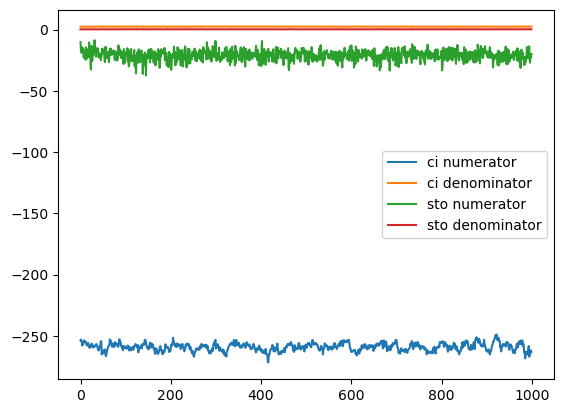

In [85]:
from matplotlib import pyplot as plt

plt.plot(numci_sp.real,label='ci numerator')
plt.plot(denci_sp.real,label='ci denominator')
plt.plot(numcr_sp.real,label='sto numerator')
plt.plot(dencr_sp.real,label='sto denominator')
plt.legend()
plt.show()

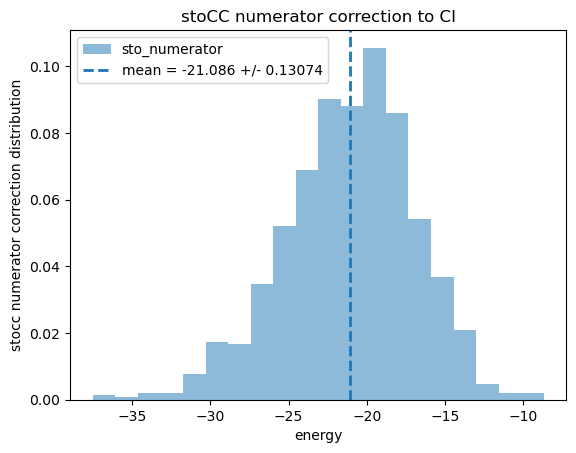

In [86]:
from matplotlib import pyplot as plt
plt.figure()
plt.hist(numcr_sp.real, bins=20, alpha=0.5, density=True, color='C0', label='sto_numerator')
mean = np.mean(numcr_sp.real)
sigma = np.std(numcr_sp.real)/np.sqrt(len(numcr_sp))
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.3f} +/- {sigma:.5f}")
plt.xlabel("energy")
plt.ylabel("stocc numerator correction distribution")
plt.title("stoCC numerator correction to CI")
plt.legend()
plt.show()

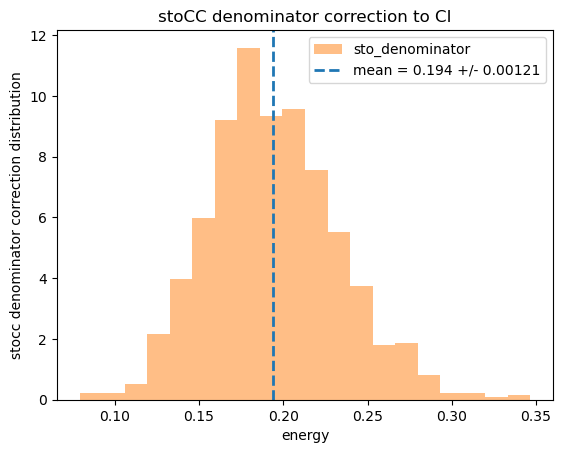

In [87]:
plt.figure()
plt.hist(dencr_sp.real, bins=20, alpha=0.5, density=True, color='C1', label='sto_denominator')
mean = np.mean(dencr_sp.real)
sigma = np.std(dencr_sp.real)/np.sqrt(len(dencr_sp))
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.3f} +/- {sigma:.5f}")
plt.xlabel("energy")
plt.ylabel("stocc denominator correction distribution")
plt.title("stoCC denominator correction to CI")
plt.legend()
plt.show()

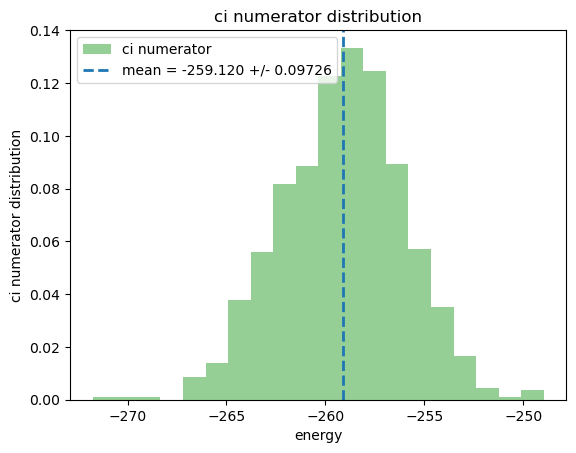

In [88]:
plt.figure()
plt.hist(numci_sp.real, bins=20, alpha=0.5, density=True, color='C2', label='ci numerator')
mean = np.mean((numci_sp).real)
sigma = np.std((numci_sp).real)/np.sqrt(len((numci_sp)))
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.3f} +/- {sigma:.5f}")
plt.xlabel("energy")
plt.ylabel("ci numerator distribution")
plt.title("ci numerator distribution")
plt.legend()
plt.show()

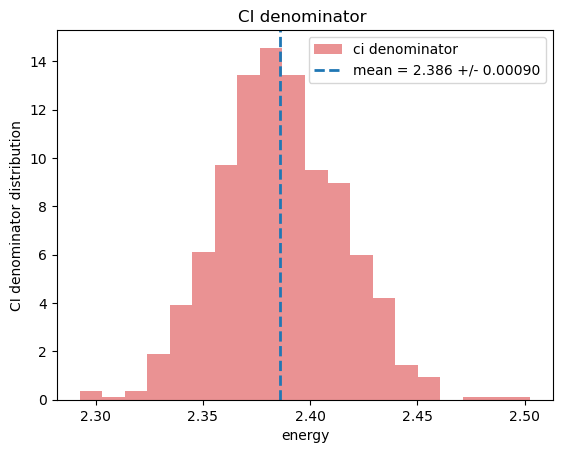

In [89]:
plt.figure()
plt.hist((denci_sp).real, bins=20, alpha=0.5, density=True, color='C3', label='ci denominator')
mean = np.mean((denci_sp).real)
sigma = np.std((denci_sp).real)/np.sqrt(len((denci_sp)))
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.3f} +/- {sigma:.5f}")
plt.xlabel("energy")
plt.ylabel("CI denominator distribution")
plt.title("CI denominator ")
plt.legend()
plt.show()

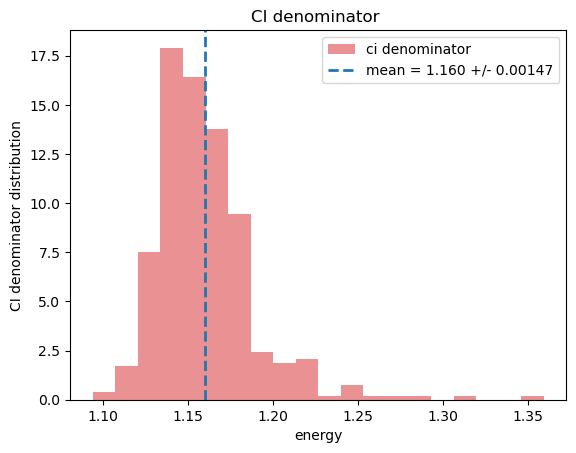

In [58]:
plt.figure()
plt.hist((denci_sp+dencr_sp).real, bins=20, alpha=0.5, density=True, color='C3', label='ci denominator')
mean = np.mean((denci_sp+dencr_sp).real)
sigma = np.std((denci_sp+dencr_sp).real)/np.sqrt(len((denci_sp+dencr_sp)))
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.3f} +/- {sigma:.5f}")
plt.xlabel("energy")
plt.ylabel("CI denominator distribution")
plt.title("CI denominator ")
plt.legend()
plt.show()

In [90]:
covci

array([[ 1.46620210e+01+0.00000000e+00j, -1.35222043e-01-8.92846085e-06j],
       [-1.35222043e-01+8.92846085e-06j,  1.24713686e-03+0.00000000e+00j]])

In [91]:
print(covcc.real)

[[ 1.46620210e+01 -1.75040481e+00 -1.35222043e-01  1.62489351e-02]
 [-1.75040481e+00  2.22202514e+01  1.63511202e-02 -2.06425603e-01]
 [-1.35222043e-01  1.63511202e-02  1.24713686e-03 -1.51798547e-04]
 [ 1.62489351e-02 -2.06425603e-01 -1.51798547e-04  1.91780772e-03]]


In [92]:
decc = [1/(denci+dencr), 
        -(numci+numcr)/(denci+dencr)**2,
        1/(denci+dencr),  
        -(numci+numcr)/(denci+dencr)**2,
        ]
covcc = np.cov([numci_sp, denci_sp, numcr_sp, dencr_sp])
ecc_err = np.sqrt(decc @ covcc @ decc) / np.sqrt((n))
print(ecc_err)

(0.0006652225137574519+7.567801275758682e-07j)


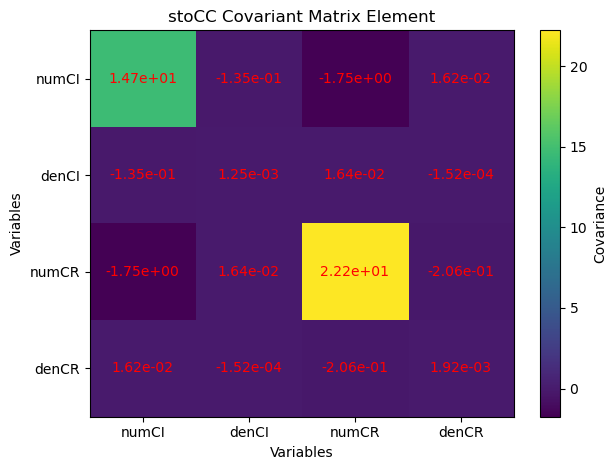

In [93]:
# 5 slater

var_names = ['numCI', 'denCI', 'numCR', 'denCR']

plt.figure()
im = plt.imshow(covcc.real, origin='upper', aspect='auto')

plt.colorbar(im, label='Covariance')

# Set tick positions
plt.xticks(np.arange(len(var_names)), var_names) #, rotation=45)
plt.yticks(np.arange(len(var_names)), var_names)

plt.xlabel('Variables')
plt.ylabel('Variables')
plt.title('stoCC Covariant Matrix Element')

plt.tight_layout()
# plt.show()

for i in range(covcc.shape[0]):
    for j in range(covcc.shape[1]):
        value = covcc.real[i, j]
        plt.text(j, i, f"{value:.2e}",
                 ha='center', va='center',
                 color='red')
plt.show()

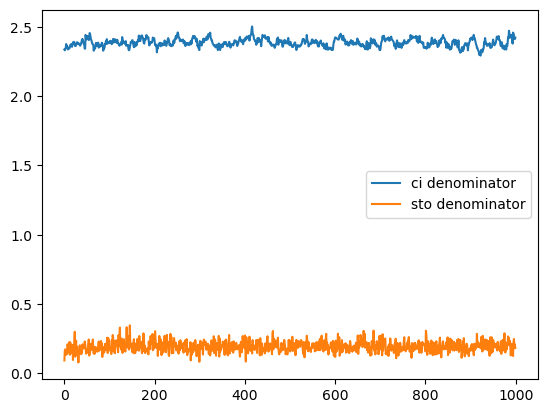

In [94]:

plt.plot(denci_sp.real,label='ci denominator')
plt.plot(dencr_sp.real,label='sto denominator')
plt.legend()
plt.show()

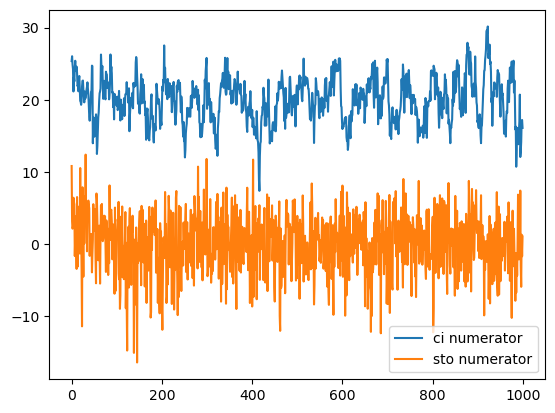

In [98]:
plt.plot((numci_sp-numci_sp.mean()).real+20,label='ci numerator')
plt.plot((numcr_sp-numcr_sp.mean()).real,label='sto numerator')
plt.legend()
plt.show()

In [99]:
ecisd_sp = (numci_sp/denci_sp).real
eccsd_sp = ((numci_sp+numcr_sp)/(denci_sp+dencr_sp)).real
ecisd = ecisd_sp.mean()
ecisd_err = np.std(ecisd_sp)/np.sqrt(len(ecisd_sp))
eccsd = eccsd_sp.mean()
eccsd_err = np.std(eccsd_sp)/np.sqrt(len(eccsd_sp))
print(f'AFQMC/CISD Energy = {ecisd:.6f} +/- {ecisd_err:.6f}')
print(f'AFQMC/CCSD Energy = {eccsd:.6f} +/- {eccsd_err:.6f}')

AFQMC/CISD Energy = -108.595134 +/- 0.000233
AFQMC/CCSD Energy = -108.599827 +/- 0.000522


In [108]:
whf_numci = whf_sp * numci_sp
whf_denci = whf_sp * denci_sp
whf_numcc = whf_sp * (numci_sp+numcr_sp)
whf_dencc = whf_sp * (denci_sp+dencr_sp)

In [110]:
whf_numci = whf_sp * numci_sp
whf_denci = whf_sp * denci_sp
ecisd_sp = (whf_numci/whf_denci).real
ecisd = ecisd_sp.mean()
ecisd_err = np.std(ecisd_sp)/np.sqrt(len(ecisd_sp))
print(f'AFQMC/CISD Energy = {ecisd:.6f} +/- {ecisd_err:.6f}')

AFQMC/CISD Energy = -108.595134 +/- 0.000233


In [ ]:
ecisd_sp = (whf_numci/whf_denci).real
eccsd_sp = (whf_numcc/whf_dencc).real
ecisd = ecisd_sp.mean()
ecisd_err = np.std(ecisd_sp)/np.sqrt(len(ecisd_sp))
eccsd = eccsd_sp.mean()
eccsd_err = np.std(eccsd_sp)/np.sqrt(len(eccsd_sp))
print(f'AFQMC/CISD Energy = {ecisd:.6f} +/- {ecisd_err:.6f}')
print(f'AFQMC/CCSD Energy = {eccsd:.6f} +/- {eccsd_err:.6f}')

AFQMC/CISD Energy = -108.595134 +/- 0.000233
AFQMC/CCSD Energy = -108.599827 +/- 0.000522


In [144]:
def blk_average(wt_sp, num_sp, den_sp, max_size=None):
    n_total = len(wt_sp)
    if max_size is None:
        max_size = n_total // 10
    # block_size = np.zeros(size_max)
    # energy = np.zeros(size_max)
    err = np.zeros(max_size)
    for i, block_size in enumerate(range(1,max_size+1)):
        n_blocks = n_total // block_size

        wt_truncated = wt_sp[:n_blocks * block_size]
        num_truncated = num_sp[:n_blocks * block_size]
        den_truncated = den_sp[:n_blocks * block_size]

        wt_num = wt_truncated * num_truncated
        wt_den = wt_truncated * den_truncated

        wt_num = wt_num.reshape(n_blocks, block_size)
        wt_den = wt_den.reshape(n_blocks, block_size)

        block_num = np.sum(wt_num, axis=1)
        block_den = np.sum(wt_den, axis=1)

        block_energy = (block_num / block_den).real
        block_mean = np.mean(block_energy)
        block_error = np.std(block_energy, ddof=1) / np.sqrt(n_blocks)
        print(f'AFQMC Energy = {block_mean:.6f} +/- {block_error:.6f}| '
              f'block size = {block_size}, Nblocks = {n_blocks}, total sample = {block_size*n_blocks}')
        # block_size[i] = b
        # energy[i] = block_mean
        err[i] = block_error
    return err


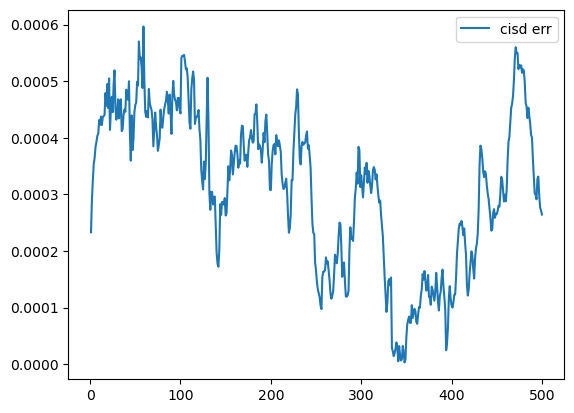

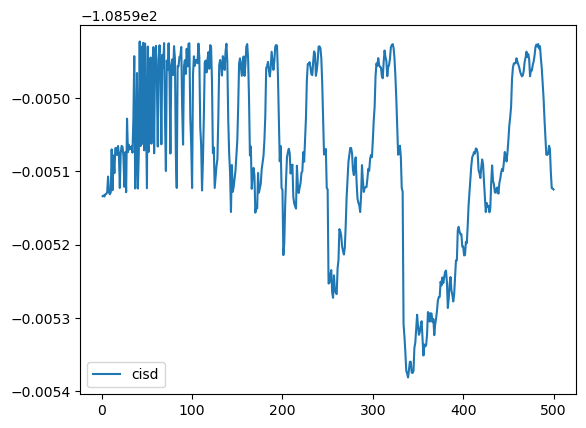

In [118]:
plt.plot(bs,err,label='cisd err')
plt.legend()
plt.show()
plt.plot(bs,e,label='cisd')
plt.legend()
plt.show()

In [ ]:
def filter_outliers(weights, num, den):

    weights_mean = weights.mean()
    sigma = np.std(weights)
    lower_bound = weights_mean - 5*sigma
    upper_bound = weights_mean + 5*sigma
    mask = (weights >= lower_bound) & (weights <= upper_bound)
    
    w_filtered = weights[mask]
    n_filtered = num[mask]
    d_filtered = den[mask]
    
    n_removed = len(weights) - len(w_filtered)
    print(f"Removed {n_removed} outliers")
    print(f"Weight bounds: [{lower_bound:.4e}, {upper_bound:.4e}]")
    
    return w_filtered, n_filtered, d_filtered

In [127]:
numcc_sp = numci_sp + numcr_sp
dencc_sp = denci_sp + dencr_sp
wt_clean, num_clean, den_clean = filter_outliers(whf_sp, numcc_sp, dencc_sp)

Removed 2 outliers (0.20% of data)
Weight bounds: [2.9829e+02, 3.0062e+02]


In [145]:
error = blk_average(wt_clean, num_clean, den_clean, max_size=None)

AFQMC Energy = -108.599834 +/- 0.000523| block size = 1, Nblocks = 998, total sample = 998
AFQMC Energy = -108.599795 +/- 0.000541| block size = 2, Nblocks = 499, total sample = 998
AFQMC Energy = -108.599786 +/- 0.000548| block size = 3, Nblocks = 332, total sample = 996
AFQMC Energy = -108.599780 +/- 0.000548| block size = 4, Nblocks = 249, total sample = 996
AFQMC Energy = -108.599767 +/- 0.000547| block size = 5, Nblocks = 199, total sample = 995
AFQMC Energy = -108.599768 +/- 0.000538| block size = 6, Nblocks = 166, total sample = 996
AFQMC Energy = -108.599749 +/- 0.000521| block size = 7, Nblocks = 142, total sample = 994
AFQMC Energy = -108.599726 +/- 0.000553| block size = 8, Nblocks = 124, total sample = 992
AFQMC Energy = -108.599706 +/- 0.000530| block size = 9, Nblocks = 110, total sample = 990
AFQMC Energy = -108.599708 +/- 0.000570| block size = 10, Nblocks = 99, total sample = 990
AFQMC Energy = -108.599703 +/- 0.000530| block size = 11, Nblocks = 90, total sample = 990

In [128]:
size_max = len(wt_clean) // 2
bs = np.zeros(size_max)
nb = np.zeros(size_max)
e = np.zeros(size_max)
err = np.zeros(size_max)
# numcc_sp = numci_sp + numcr_sp
# dencc_sp = denci_sp + dencr_sp
for i,block_size in enumerate(range(1,size_max+1)):
    n_total = len(wt_clean)
    n_blocks = n_total // block_size

    whf_truncated = wt_clean[:n_blocks * block_size]
    numcc_truncated = num_clean[:n_blocks * block_size]
    dencc_truncated = den_clean[:n_blocks * block_size]

    whf_numcc = whf_truncated * numcc_truncated
    whf_dencc = whf_truncated * dencc_truncated

    whf_numcc = whf_numcc.reshape(n_blocks, block_size)
    whf_dencc = whf_dencc.reshape(n_blocks, block_size)

    block_numcc = np.sum(whf_numcc, axis=1)
    block_dencc = np.sum(whf_dencc, axis=1)

    block_energy = (block_numcc/block_dencc).real
    energy_mean = np.mean(block_energy)
    energy_error = np.std(block_energy, ddof=1) / np.sqrt(n_blocks)
    print(f'AFQMC/CCSD Energy = {energy_mean:.6f} +/- {energy_error:.6f}| block size = {block_size}, Nblocks = {n_blocks}')
    bs[i] = block_size
    nb[i] = n_blocks
    e[i] = energy_mean
    err[i] = energy_error

AFQMC/CCSD Energy = -108.599834 +/- 0.000523| block size = 1, Nblocks = 998
AFQMC/CCSD Energy = -108.599795 +/- 0.000541| block size = 2, Nblocks = 499
AFQMC/CCSD Energy = -108.599786 +/- 0.000548| block size = 3, Nblocks = 332
AFQMC/CCSD Energy = -108.599780 +/- 0.000548| block size = 4, Nblocks = 249
AFQMC/CCSD Energy = -108.599767 +/- 0.000547| block size = 5, Nblocks = 199
AFQMC/CCSD Energy = -108.599768 +/- 0.000538| block size = 6, Nblocks = 166
AFQMC/CCSD Energy = -108.599749 +/- 0.000521| block size = 7, Nblocks = 142
AFQMC/CCSD Energy = -108.599726 +/- 0.000553| block size = 8, Nblocks = 124
AFQMC/CCSD Energy = -108.599706 +/- 0.000530| block size = 9, Nblocks = 110
AFQMC/CCSD Energy = -108.599708 +/- 0.000570| block size = 10, Nblocks = 99
AFQMC/CCSD Energy = -108.599703 +/- 0.000530| block size = 11, Nblocks = 90
AFQMC/CCSD Energy = -108.599758 +/- 0.000566| block size = 12, Nblocks = 83
AFQMC/CCSD Energy = -108.599693 +/- 0.000574| block size = 13, Nblocks = 76
AFQMC/CCSD E

In [130]:
num = wt_clean * num_clean
den = wt_clean * den_clean
energy = (np.sum(num)/np.sum(den)).real
print(energy)

-108.5997430990419


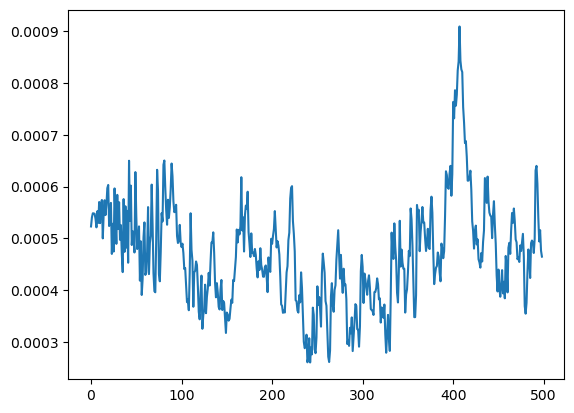

In [140]:
plt.plot(error,label='ccsd err')

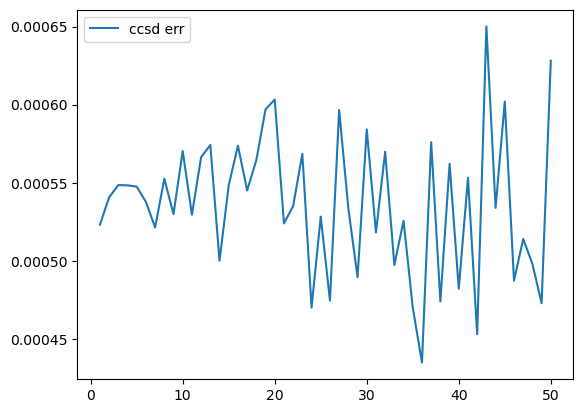

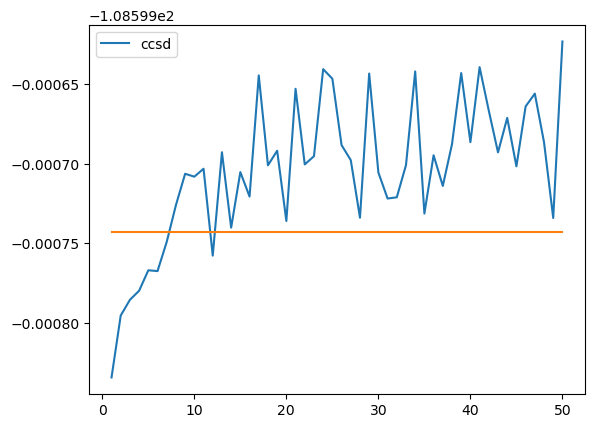

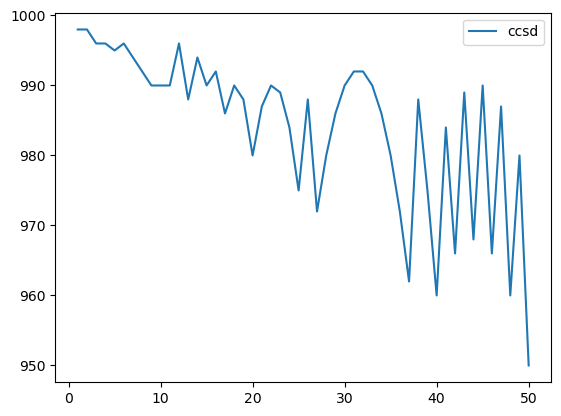

In [133]:
n=50
plt.plot(bs[:n],err[:n],label='ccsd err')
plt.legend()
plt.show()
plt.plot(bs[:n],e[:n],label='ccsd')
plt.plot(bs[:n],[energy]*len(bs[:n]))
plt.legend()
plt.show()
plt.plot(bs[:n],nb[:n]*bs[:n],label='ccsd')
plt.legend()
plt.show()

In [ ]:
def calculate_blocked_energy(num_samples, den_samples, block_size):
    """
    Calculates E = mean(block_avg_num / block_avg_den) 
    and the associated standard error.
    """
    n_total = len(num_samples)
    n_blocks = n_total // block_size
    
    if n_blocks < 2:
        raise ValueError(f"Block size {block_size} is too large for {n_total} samples.")

    # 1. Truncate data to fit into clean blocks
    num_truncated = num_samples[:n_blocks * block_size]
    den_truncated = den_samples[:n_blocks * block_size]

    # 2. Reshape into (n_blocks, block_size)
    num_reshaped = num_truncated.reshape(n_blocks, block_size)
    den_reshaped = den_truncated.reshape(n_blocks, block_size)

    # 3. Calculate the mean of numerator and denominator within each block
    block_num_means = np.mean(num_reshaped, axis=1)
    block_den_means = np.mean(den_reshaped, axis=1)

    # 4. Calculate the ratio for each block (E_j = <N>_j / <D>_j)
    block_ratios = (block_num_means / block_den_means).real

    # 5. Final Energy is the mean of these block ratios
    energy_mean = np.mean(block_ratios)
    
    # 6. Error is the Standard Error of the Mean (SEM) of the block ratios
    # We use ddof=1 for the unbiased sample standard deviation
    energy_error = np.std(block_ratios, ddof=1) / np.sqrt(n_blocks)

    return energy_mean, energy_error

# Usage with your data:
# ecisd, ecisd_err = calculate_blocked_energy(whf_numci, whf_denci, block_size=10)

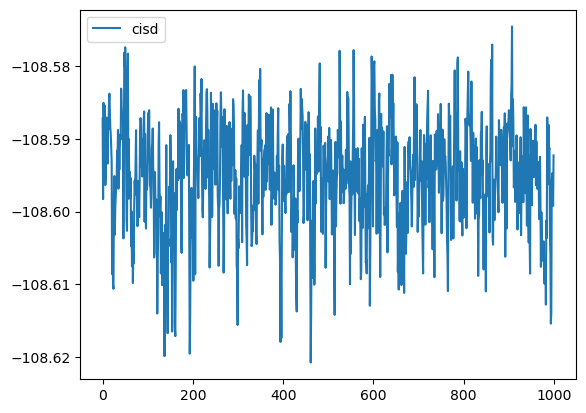

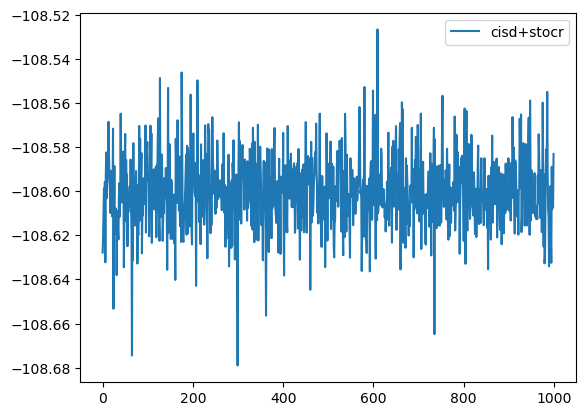

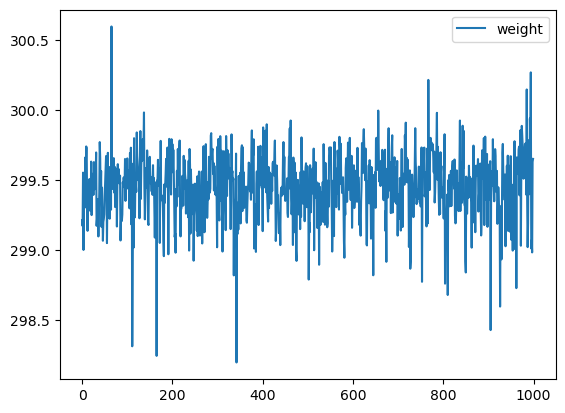

In [100]:
plt.plot(ecisd_sp,label='cisd')
# plt.plot(eccsd_sp.real,label='cisd+stocr')
plt.legend()
plt.show()

plt.plot(eccsd_sp.real,label='cisd+stocr')
plt.legend()
plt.show()

plt.plot(whf_sp,label='weight')
plt.legend()
plt.show()

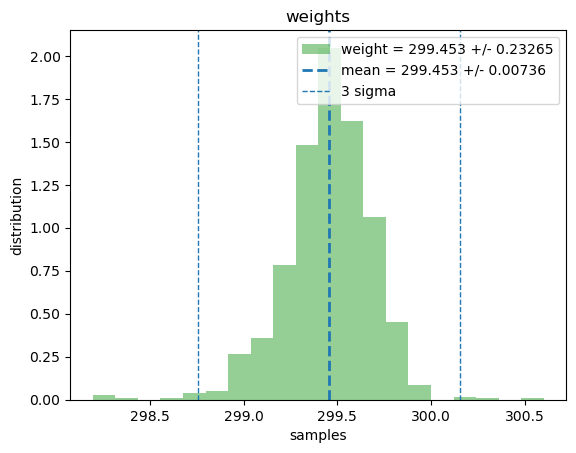

In [105]:
plt.figure()
mean = np.mean(whf_sp)
sigma = np.std(whf_sp)
sigma_mean = np.std(whf_sp)/np.sqrt(len(whf_sp))
plt.hist(whf_sp, bins=20, alpha=0.5, density=True, color='C2', label=f'weight = {mean:.3f} +/- {sigma:.5f}')
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.3f} +/- {sigma_mean:.5f}")
plt.axvline(mean+sigma*3, linestyle="--", linewidth=1, label=f"3 sigma")
plt.axvline(mean-sigma*3, linestyle="--", linewidth=1)
plt.xlabel("samples")
plt.ylabel("distribution")
plt.title("weights")
plt.legend()
plt.show()

In [56]:
whf_jk = whf - whf_sp
numci_jk = (whf_numci - whf_sp * numci_sp)
denci_jk = (whf_denci - whf_sp * denci_sp)
numcr_jk = (whf_numcr - whf_sp * numcr_sp)
dencr_jk = (whf_dencr - whf_sp * dencr_sp)

nsample_jk = len(whf_jk)
ecc_jk = (numci_jk + numcr_jk) / (denci_jk + dencr_jk)
ecc_jk_mean = np.sum(ecc_jk) / (nsample_jk)
ecc_jk_err = np.sqrt(np.sum((ecc_jk-ecc_jk_mean)**2) * (nsample_jk-1)/nsample_jk)
print(f'Jackknife CCSD Energy: {ecc_jk_mean.real:.6f} +/- {ecc_jk_err.real:.6f}')

Jackknife CCSD Energy: -108.598696 +/- 0.000622


In [67]:
import numpy as np

def block_jackknife(weights, n_ci, n_cr, d_ci, d_cr, block_size):
    """
    Performs Block Jackknife on the ratio estimator E = (<N_ci> + <N_cr>) / (<D_ci> + <D_cr>)
    """
    # 1. Ensure all inputs are numpy arrays
    w = np.array(weights)
    n1, n2 = np.array(n_ci), np.array(n_cr)
    d1, d2 = np.array(d_ci), np.array(d_cr)
    
    # 2. Calculate weighted components per sample
    # (Total Numerator and Total Denominator contributions per sample)
    num_samples = (len(w) // block_size) * block_size
    # print(num_samples)
    weighted_num = (w * (n1 + n2))[:num_samples]
    weighted_den = (w * (d1 + d2))[:num_samples]
    
    # 3. Reshape and sum into Blocks
    num_blocks = num_samples // block_size
    # We sum the weighted values within each block
    block_sums_num = weighted_num.reshape(num_blocks, block_size).sum(axis=1)
    block_sums_den = weighted_den.reshape(num_blocks, block_size).sum(axis=1)
    
    # 4. Calculate Global Totals
    total_num = np.sum(block_sums_num)
    total_den = np.sum(block_sums_den)
    
    # 5. Generate Jackknife Estimates (Leave-One-Block-Out)
    # e_jk[j] is the energy calculated excluding block j
    e_jk = (total_num - block_sums_num) / (total_den - block_sums_den)
    
    # 6. Calculate Jackknife Statistics
    m = num_blocks
    mean_jk = np.mean(e_jk)
    # The (m-1) factor is the standard Jackknife variance scaling
    err_jk = np.sqrt((m - 1) / m * np.sum((e_jk - mean_jk)**2))
    
    return err_jk.real, block_size, num_blocks

In [68]:
nblk = None
# blks = [1,2,3,4,5,6,7,8,9,10]
# def blocking(whf_sp, numci_sp, numcr_sp, denci_sp, dencr_sp, nblk=None):
if nblk is None:
    nblk = len(whf_sp) // 10
# e = np.zeros(nblk)
err = np.zeros(nblk)
thresh = 1.05
print(f'b_size n_blk Error_JK')
for i in range(nblk):
    err[i], block_size, num_blocks = block_jackknife(whf_sp, numci_sp, numcr_sp, denci_sp, dencr_sp, block_size=i+1)
    print(f'{block_size} {num_blocks}  {err[i]:.6f}')
        # if err[i] < err[i-1]*thresh:
        #     break
    # return err[i]

b_size n_blk Error_JK
1 400  0.000622
2 200  0.000531
3 133  0.000432
4 100  0.000485
5 80  0.000414
6 66  0.000424
7 57  0.000422
8 50  0.000521
9 44  0.000323
10 40  0.000540
11 36  0.000393
12 33  0.000529
13 30  0.000423
14 28  0.000668
15 26  0.000491
16 25  0.000478
17 23  0.000550
18 22  0.000491
19 21  0.000567
20 20  0.000527
21 19  0.000634
22 18  0.000579
23 17  0.000720
24 16  0.000516
25 16  0.000468
26 15  0.000565
27 14  0.000497
28 14  0.000721
29 13  0.000685
30 13  0.000669
31 12  0.000768
32 12  0.000853
33 12  0.000634
34 11  0.000850
35 11  0.000783
36 11  0.000846
37 10  0.000551
38 10  0.000386
39 10  0.000909
40 10  0.000863


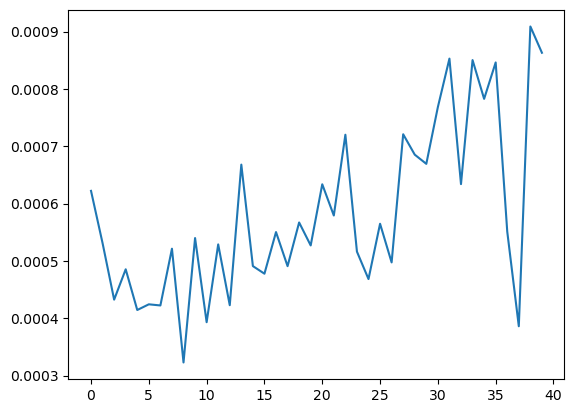

In [69]:
plt.plot(err)

In [ ]:

def find_outliers_mad(x, threshold=20.0):
    x = np.asarray(x)

    median = np.median(x)
    mad = np.median(np.abs(x - median))

    # Avoid division-by-zero if all values identical
    if mad == 0:
        return x, np.array([], dtype=int)

    modified_z = 0.6745 * (x - median) / mad
    mask_clean = np.abs(modified_z) <= threshold

    # cleaned = x[mask]
    removed_idx = np.where(~mask_clean)[0]

    return mask_clean, removed_idx

def reomve_outliers(data, mask_clean):
    return [x[mask_clean] for x in data]

In [88]:
mask_clean, outlier_idx = find_outliers_mad(ecc_jk.real, threshold=20.0)
print(outlier_idx)
print(mask_clean.sum())

[673 852]
998


In [90]:
data = [whf_sp, numci_sp, denci_sp, numcr_sp, dencr_sp]
[whf_clean, numci_clean, denci_clean, numcr_clean, dencr_clean] = reomve_outliers(data, mask_clean)

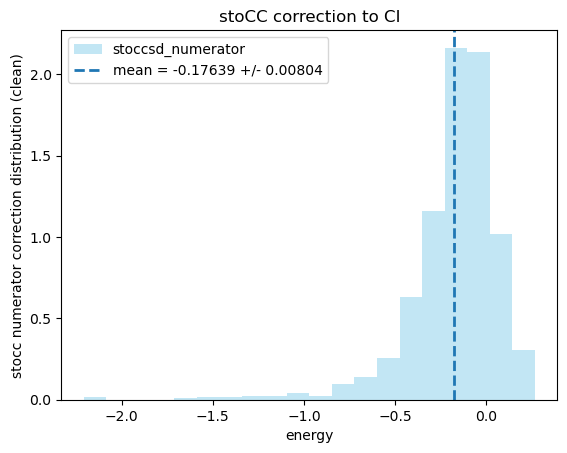

In [95]:
plt.figure()
# plt.hist(energy1.real, bins=10, alpha=0.6, color='skyblue', label='full-stoccsd')
plt.hist(numcr_clean.real, bins=20, alpha=0.5, density=True, color='skyblue', label='stoccsd_numerator')
mean = np.mean(numcr_clean.real)
sigma = np.std(numcr_clean.real)/np.sqrt(len(numcr_clean))
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.5f} +/- {sigma:.5f}")
# plt.axvline(mycc.e_tot, linestyle="-", linewidth=2, color='black', label=f"CCSD energy = {mycc.e_tot:.3f}")
# plt.hist(energy2.real, bins=10, alpha=0.5, density=True, color='purple', label='cisd-stoccsd')
plt.xlabel("energy")
plt.ylabel("stocc numerator correction distribution (clean)")
plt.title("stoCC correction to CI")
plt.legend()
plt.show()

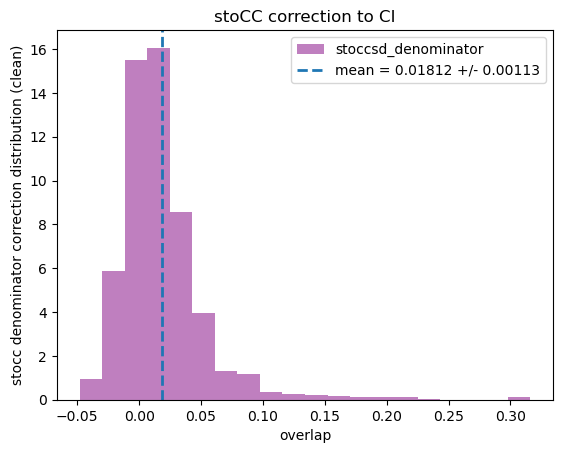

In [94]:
plt.figure()
plt.hist(dencr_clean.real, bins=20, alpha=0.5, density=True, color='purple', label='stoccsd_denominator')
mean = np.mean(dencr_clean.real)
sigma = np.std(dencr_clean.real)/np.sqrt(len(dencr_clean))
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.5f} +/- {sigma:.5f}")
plt.xlabel("overlap")
plt.ylabel("stocc denominator correction distribution (clean)")
plt.title("stoCC correction to CI")
plt.legend()
plt.show()

In [96]:
whf = np.sum(whf_clean)
whf_numci = np.sum(whf_clean * numci_clean)
whf_denci = np.sum(whf_clean * denci_clean)
whf_numcr = np.sum(whf_clean * numcr_clean)
whf_dencr = np.sum(whf_clean * dencr_clean)

In [99]:
(whf_numci + whf_numcr) / (whf_denci + whf_dencr)

np.complex128(-8.76952657069782+0.00014324040333053414j)

In [100]:
whf_jk = whf - whf_clean
numci_jk = (whf_numci - whf_clean * numci_clean) / whf_jk
denci_jk = (whf_denci - whf_clean * denci_clean) / whf_jk
numcr_jk = (whf_numcr - whf_clean * numcr_clean) / whf_jk
dencr_jk = (whf_dencr - whf_clean * dencr_clean) / whf_jk

#CCSD
ecc_jk = (numci_jk + numcr_jk) / (denci_jk + dencr_jk)
# for i in range(len(whf_jk)):
#     print(f'  {i+1}  {ecc_jk.real[i]:.6f}')
ecc_jk_mean = ecc_jk.mean()
ecc_jk_err = np.std(ecc_jk) * np.sqrt(len(ecc_jk))
print(f'{ecc_jk_mean.real:.6f} +/- {ecc_jk_err.real:.6f}')

-8.769527 +/- 0.001809


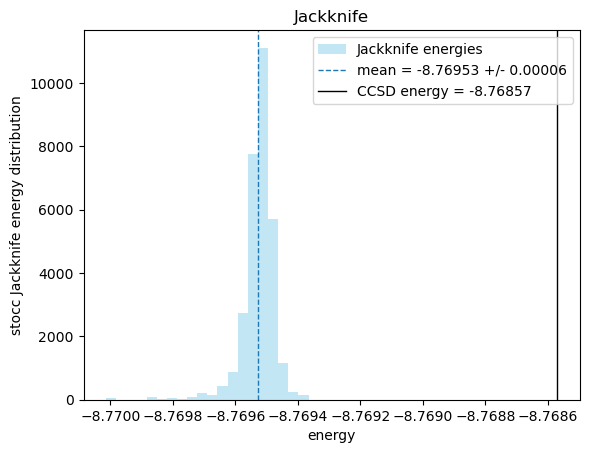

In [101]:
plt.figure()
plt.hist(ecc_jk.real, bins=20, alpha=0.5, density=True, color='skyblue', label='Jackknife energies')
mean = np.mean(ecc_jk.real)
sigma = np.std(ecc_jk.real)
plt.axvline(mean, linestyle="--", linewidth=1, label=f"mean = {mean:.5f} +/- {sigma:.5f}")
plt.axvline(mycc.e_tot, linestyle="-", linewidth=1, color='black', label=f"CCSD energy = {mycc.e_tot:.5f}")
plt.xlabel("energy")
plt.ylabel("stocc Jackknife energy distribution")
plt.title("Jackknife")
plt.legend()
plt.show()